# Podstawowe warstwy sieci neuronowych

Podstawowym elementem każdej sieci neuronowej są tzw. layers, czyli warstwy, nieważne czy to wejściowa, ukryta czy wejściowa warstwa, informacje, które będą przedstawione w poniższym rozdziale, będą tyczyć się każdej z nich.

# Dense Layer

Zaczniemy od najprostszej z nich, czyli warstwy liniowej, w TensorFlow zaimplementowanej jako Dense Layer. Warstwa wspominaną już prostą operację liniową:



y = W * x + b

w - wagi naszej sieci 
b - bias, odchylenie naszej sieci

Najważniejszymi parametrami, które będą tutaj istotne, są:

- units – określający ile neuronów będzie posiadać nasza warstwa,
- activation – funkcja aktywacyjna, która ma być użyta dla tej warstwy,
- name – nazwa, jaką chcemy nadać naszej warstwie. Domyślnie Dense1, Dense2, ..

Zazwyczaj nie ma potrzeby zmieniania pozostałych hiperparametrów i nie zalecamy, aby je ruszać bez dokładnej wiedzy i świadomości, dlaczego chcemy je zmienić i na jakie wartości.

Stworzenie takiej warstwy sprowadza się do:

import tensorflow as tf

dense_layer = tf.keras.layers.Dense(32)

 albo bardziej dosłownie

dense_layer = tf.keras.layers.Dense(units=32)

Powyższa instrukcja tworzy warstwę liniową z 32 neuronami.

# Podstawy dzialania

Każda z opisywanych warstw działa następująco.

Dostajemy wartości wejściowe o rozmiarze (batch_size, data_shape).

        - batch_size – hiperparametr, który był opisany w module 2. Mówi nam, ile sztuk danych wejściowych nasz model dostaje. Ponieważ komputery bazują na systemie dwójkowym, zazwyczaj wartość tego parametru jest wielokrotnością 2: 2, 4, 8, 16, 32, 64, itd.

        - data_shape - rozmiar danych wejściowych, czyli ilość cech danego zbioru. Jeżeli mamy do czynienia ze zdjęciami, rozmiar naszych danych może wynosić 24x24, jeżeli mamy dane, np. ze zbioru "Titanic" z modułu 1 rozmiar danych wynosi np. 10x1.

Czasami musimy podać dodatkowy parametr dla pierwszego modułu naszego modelu:

    - input_shape=(data_shape,) - mówi naszemu modelowi, jaki jest rozmiar danych wejściowych. Co ważne – tylko dla pierwszej warstwy modelu!

        
Datashape musi mieć format (wymiar1, wymiar2). Jeśli mamy do czynienia tylko z jednowymiarowymi danymi np. z Titanica, piszemy input_shape=(24,). Jeżeli mamy do czynienia z np. obrazkami, piszemy input_shape=(24,24).

# Flatten Layer

Kolejną warstwą, stosowaną zazwyczaj jako pierwsza, jest Flatten Layer.

Warstwa ta służy do "spłaszczania" naszych danych wejściowych z wielowymiarowych do jednowymiarowych. Jest to czasami przydatne, jeśli chcemy przekazywać nasze dane do Dense layer, opisanej poprzednio, albo jeśli nie ma potrzeby procesowania danych wielowymiarowych.

Jej działanie można podsumować jako:

- pierwszy wymiar danych zostaw bez zmian,
- każdy kolejny doklej na koniec poprzedniego.

Można to porównać do ładowania kontenerów początkowo ustawionych w regularny stos, w warstwach i rzędach na wagony pociągu towarowego, jeden za drugim, po kolei warstwa za warstwą, rząd za rzędem w jeden długi, liniowy skład.

flatten = tf.keras.layers.Flatten()

Bardzo często stosuje się ją na początku modelu albo pod koniec modelu, kiedy mamy już przetworzone dane przez naszą sieć i chcemy uzyskać wynik wyjściowy np. zaklasyfikować czy dane zdjęcie przedstawia psa, czy kota.

# Tworzenie sieci neuronowej w TensorFlow

- Budowanie modeli można porównać do składania klocków Lego. Większość architektur sieci ML używa ogólnie znanych warstw, lecz poukładanych w specyficzny sposób.

- Pierwszy sposób tworzenia modelu sieci neuronowych bazuje na zastosowaniu tzw. Sequential model. Mając już zbudowany model, aby go użyć, musimy wywołać:

output = nasz_model(dane_wejsciowe)

# Sequential model 

Jest to ułożenie wielu warstw w sposób sekwencyjny (jedna po drugiej), gdzie każda warstwa ma dokładnie jedno wejście i jedno wyjście. Przez wejście warstwy rozumiemy wejścia wszystkich jej neuronów traktowane jako całość.

In [8]:
#cwiczenie

Ćwiczenie
Bazując na dokumentacji i przykładach w niej zawartych, stwórzmy teraz prosty model sekwencyjny o następujących właściwościach:

Spłaszczenie danych wejściowych.
Warstwa liniowa z 16 neuronami o nazwie: input_layer.
Warstwa liniowa z 32 neuronami o nazwie: hidden_layer.
Warstwa liniowa z 4 neuronami o nazwie: output_layer.
nazwa naszego modelu to seq_model.
Następnie użyjmy wygenerowanych danych, jako wejścia do naszego modelu:

input_data = tf.ones((16, 3, 3))

In [9]:
# Importuje bibliotekę TensorFlow, używaną do tworzenia i trenowania sieci neuronowych.
import tensorflow as tf

# Importuje moduł zawierający gotowe warstwy sieci neuronowych, np. Flatten i Dense.
import tensorflow.keras.layers as layers


# --- Utworzenie modelu: sposób pierwszy ---

# Tworzy pusty model sekwencyjny, w którym warstwy będą wykonywane jedna po drugiej.
seq_model = tf.keras.Sequential()

# Spłaszcza dane wejściowe o wymiarach 3 × 3 do jednego wektora zawierającego 9 wartości.
# input_shape określa oczekiwany kształt pojedynczego przykładu wejściowego.
seq_model.add(layers.Flatten(input_shape=[3, 3]))

# Dodaje warstwę gęstą zawierającą 16 neuronów.
# Każdy neuron tej warstwy jest połączony ze wszystkimi wartościami poprzedniej warstwy.
seq_model.add(layers.Dense(16, name="dense_16"))

# Dodaje warstwę ukrytą zawierającą 32 neurony.
seq_model.add(layers.Dense(32, name="dense_32"))

# Dodaje warstwę wyjściową zwracającą 4 wartości.
seq_model.add(layers.Dense(4, name="dense_output"))


# --- Utworzenie modelu: sposób drugi ---

# Tworzy model sekwencyjny i od razu przekazuje do niego listę wszystkich warstw.
seq_model_2 = tf.keras.Sequential([
    # Spłaszcza każdy przykład wejściowy do jednowymiarowego wektora.
    layers.Flatten(),

    # Przekazuje spłaszczone dane do warstwy zawierającej 16 neuronów.
    layers.Dense(16, name="dense_16"),

    # Przekazuje wyniki do warstwy ukrytej zawierającej 32 neurony.
    layers.Dense(32, name="dense_32"),

    # Generuje 4 końcowe wartości wyjściowe dla każdego przykładu.
    layers.Dense(4, name="dense_output")
])


# Przekazuje dane zapisane w zmiennej input_data przez wszystkie warstwy drugiego modelu.
output = seq_model_2(input_data)

# Wyświetla wartości zwrócone przez model.
print(output)

tf.Tensor(
[[ 0.17037031  0.38763723  0.4497612   1.1449187 ]
 [ 0.6945107   0.02493751  0.0856341   0.5175584 ]
 [-0.01438463  0.4166901   0.62925255  1.0858668 ]
 [ 0.15023321  0.24577904  0.33459732  1.1082817 ]
 [ 0.2602246   0.03218496  0.15633701  0.95197654]], shape=(5, 4), dtype=float32)


In [10]:
# Tworzy 5 przykładowych obserwacji.
# Każda obserwacja jest macierzą o wymiarach 3 × 3.
input_data = tf.random.uniform(shape=(5, 3, 3))

# Przekazuje dane przez model.
output = seq_model_2(input_data)

# Wyświetla wynik. Jego kształt będzie równy (5, 4).
print(output)

tf.Tensor(
[[ 0.15972725 -0.13389012  0.21847028  0.91555417]
 [ 0.272775    0.10153213  0.44824725  1.4539678 ]
 [ 0.38592103 -0.05215943  0.24579483  1.2367709 ]
 [ 0.26375285 -0.18675798  0.48413637  0.57169765]
 [ 0.23410268 -0.03094348  0.19559225  0.549812  ]], shape=(5, 4), dtype=float32)


kod tworzy dwa modele sieci neuronowej o praktycznie takiej samej budowie, ale przy użyciu dwóch różnych zapisów. Dane są najpierw spłaszczane, a następnie przechodzą przez warstwy liczące kolejno 16, 32 i 4 neurony. Na końcu drugi model przetwarza input_data, a wynik zostaje wyświetlony.
Warto pamiętać, że:
input_data musi zostać wcześniej utworzone.
W warstwach Dense nie podano funkcji aktywacji, więc domyślnie używana jest funkcja liniowa.
Nazwa input_layer jest trochę myląca — jest to warstwa Dense, a nie właściwa warstwa wejściowa.

ak widać, dzięki TensorFlow stworzenie i uruchomienie modelu nie jest takie trudne, jak by się mogło wydawać. Jest tu jednak małe "ale" – to, co przed chwilą zrobiliśmy, pominęło zasadniczą fazę w procesie ML, czyli trenowanie modelu!

Powyższy przykład pokazał nam, jak na bazie danych wejściowych uzyskać wynik z naszej sieci, lecz jak wiemy z poprzednich rozdziałów, najpierw musimy naszą sieć wytrenować.

In [11]:
import numpy as np
import tensorflow as tf

train, test = tf.keras.datasets.fashion_mnist.load_data()

# wydobycie obrazów oraz labelek
images, labels = train

# normalizacja wartości pikseli (maks. wartość
# wynosi 255.0, czyli aby znormalizować nasze dane,
# musimy podzielić każdy piksel przez maks. wartość)
images = images/255.0

# zapisujemy dane jako int
labels = labels.astype(np.int32)


Następnie musimy przerobić nasze dane na format zrozumiały dla Tensorflow, czyli na Dataset. Jest to zbiór danych zrozumiały dla tensorflowa, w którym możemy iterować się jak po zwykłej liście pythonowej. Aby stworzyć taki zbiór, musimy użyć metody:

dataset = tf.data.Dataset.from_tensor_slices(list_pythonowa)

# Tensor

Jest to podstawowy typ danych używany przez frameworki ML w Pythonie. To nic innego jak wektor/macierz danych, tylko inaczej nazwana.

Spróbujmy teraz stworzyć dataset oraz za pomocą dostępnych metod (które można znaleźć w dokumentacji) ustawmy batch_size na 32, oraz przetasujmy nasz zbiór (shuffle).

In [12]:
import tensorflow as tf
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = \
    train_test_split(images, labels, test_size=0.1)

# stworzenie zbioru typu Dataset z naszej listy
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))

# ustawienie batch_size na 32 oraz przetasowanie na bazie 1000 próbek
train_ds = train_ds.shuffle(1000).batch(32)

Następnie stwórzmy nasz model.

- Na wejściu musimy spłaszczyć dane.
- Należy wybrać odpowiednią funkcję aktywacyjną dla kolejnych warstw.
- Ilość neuronów warstw ukrytych powinna maleć im bliżej wyjścia naszego modelu (zazwyczaj takie podejście działa najlepiej np. 300, 200, 100, 5).
- Wyjście powinno mieć tyle neuronów, ile jest klas w naszym zbiorze.

In [13]:
# Tworzy sekwencyjny model sieci neuronowej, w którym warstwy działają kolejno.
f_mnist_model = tf.keras.Sequential([

    # Spłaszcza dwuwymiarowy obraz, np. 28 × 28 pikseli,
    # do jednowymiarowego wektora składającego się z 784 wartości.
    layers.Flatten(),

    # Dodaje pierwszą warstwę ukrytą zawierającą 300 neuronów.
    # Funkcja ReLU zamienia wartości ujemne na 0, a dodatnie pozostawia bez zmian.
    layers.Dense(300, activation="relu"),

    # Dodaje drugą warstwę ukrytą zawierającą 150 neuronów.
    # Otrzymuje ona i przetwarza wyniki z poprzedniej warstwy.
    layers.Dense(150, activation="relu"),

    # Dodaje warstwę wyjściową zawierającą 10 neuronów,
    # ponieważ zbiór Fashion MNIST posiada 10 klas ubrań.
    # Softmax przekształca wyniki neuronów w rozkład prawdopodobieństwa.
    # Suma 10 wartości zwróconych przez tę warstwę wynosi około 1.
    layers.Dense(10, activation="softmax")
])

Model klasyfikuje obrazy Fashion MNIST. Najpierw zamienia obraz 28 × 28 na wektor 784 wartości, następnie przetwarza go w dwóch warstwach ukrytych, a na końcu zwraca prawdopodobieństwo przynależności obrazu do każdej z 10 klas. Klasa z najwyższym prawdopodobieństwem jest przewidywaniem modelu.

Została tutaj użyta funkcja aktywacyjna softmax, gdyż chcemy określić jaka klasa była na zdjęciu. Jeżeli w pierwszej warstwie podamy rozmiar danych wejściowych, możemy wypisać sobie podsumowanie naszego modelu.

Zmieniona pierwsza warstwa musiałaby wyglądać następująco:

tf.keras.Sequential([
    layers.Flatten(input_shape=[24, 24]),
    ...
])

In [14]:
# Tworzy sekwencyjny model sieci neuronowej, w którym warstwy działają kolejno.
f_mnist_model = tf.keras.Sequential([

    # Spłaszcza dwuwymiarowy obraz, np. 28 × 28 pikseli,
    # do jednowymiarowego wektora składającego się z 784 wartości.
    layers.Input(shape=(28, 28)),

    # Spłaszcza obraz 28 × 28 do wektora 784 wartości.
    layers.Flatten(),

    # Dodaje pierwszą warstwę ukrytą zawierającą 300 neuronów.
    # Funkcja ReLU zamienia wartości ujemne na 0, a dodatnie pozostawia bez zmian.
    layers.Dense(300, activation="relu"),

    # Dodaje drugą warstwę ukrytą zawierającą 150 neuronów.
    # Otrzymuje ona i przetwarza wyniki z poprzedniej warstwy.
    layers.Dense(150, activation="relu"),

    # Dodaje warstwę wyjściową zawierającą 10 neuronów,
    # ponieważ zbiór Fashion MNIST posiada 10 klas ubrań.
    # Softmax przekształca wyniki neuronów w rozkład prawdopodobieństwa.
    # Suma 10 wartości zwróconych przez tę warstwę wynosi około 1.
    layers.Dense(10, activation="softmax")
])

Wtedy możemy użyć metody summary, aby wypisać podsumowanie.

In [15]:
f_mnist_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 150)            │        45,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,160 (1.08 MB)

 Trainable params: 282,160 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

Zauważmy, że nasz Output Shape ma pierwszy parametr None. Jest to wypełniacz naszego batch_size, gdyż na tym etapie nie wiadomo, jaki on będzie.

Teraz, kiedy mamy model, nasz zbiór jest w formacie zrozumiałym dla TensorFlow, możemy zająć się szkoleniem naszego modelu.

In [16]:
# od chata # 

Ta tabela to podsumowanie budowy modelu (model.summary()). Każdy wiersz opisuje jedną warstwę sieci.


Znaczenie kolumn:

- Layer (type) — nazwa i rodzaj warstwy.
- Output Shape — kształt danych po przejściu przez warstwę.
- Param # — liczba parametrów, których model może się nauczyć, czyli wag i biasów.
- None oznacza dowolną liczbę obrazów przetwarzanych jednocześnie. Na przykład (None, 300) znaczy: dowolna liczba obrazów, po 300 wartości dla każdego obrazu.

Poszczególne warstwy
- flatten_6 (Flatten) → (None, 576) Warstwa spłaszcza każdy obraz do wektora zawierającego 576 wartości.
- 
Prawdopodobnie obrazy mają rozmiar 24 × 24, ponieważ:
- 24 × 24 = 576
- Flatten nie wykonuje obliczeń z użyciem wag, więc nie ma parametrów:
Param # = 0


dense_3 (Dense) → (None, 300) Pierwsza warstwa gęsta ma 300 neuronów. Każdy neuron otrzymuje wszystkie 576 wartości z warstwy Flatten.
Każdy neuron ma:
576 wag,
1 bias.

Dlatego:
- 576 × 300 + 300 = 173 100
  
Można to również zapisać jako:
- (576 + 1) × 300 = 173 100
  
dense_4 (Dense) → (None, 150) Druga warstwa gęsta ma 150 neuronów. Każdy neuron otrzymuje 300 wartości z poprzedniej warstwy:
- 300 × 150 + 150 = 45 150
  
Czyli 45 000 wag i 150 biasów.


dense_5 (Dense) → (None, 10) Warstwa wyjściowa ma 10 neuronów, ponieważ model rozpoznaje 10 klas.
Każdy neuron otrzymuje 150 wartości:
- 150 × 10 + 10 = 1 510
- Czyli 1 500 wag i 10 biasów.
- 
Cały przepływ danych
obraz 24 × 24
      ↓ Flatten
576 wartości
      ↓ Dense
300 wartości
      ↓ Dense
150 wartości
      ↓ Dense + Softmax
10 prawdopodobieństw klas
  
Łączna liczba parametrów modelu wynosi:
- 173 100 + 45 150 + 1 510 = 219 760

Model podczas treningu dopasowuje właśnie te 219 760 parametrów. Sama liczba parametrów nie oznacza liczby neuronów — obejmuje wszystkie połączenia między neuronami oraz biasy.

# Kompilacja modelu

Kompilacja jest to proces, w którym mówimy TensorFlow jakiego optimizera, jakiej funkcji błędu oraz jakiej metryki powinien użyć podczas nauki.

W tym momencie warto zaznaczyć, że wszystkie operacje dostępne na modelach są opisane w klasie Model, gdyż nie ważne, jakiej metody użyjemy do stworzenia naszej sieci, każda z nich dziedziczy po klasie Model.

Spróbujmy teraz skompilować nasz model, używając:

- optimizer 'adam',
- loss function 'sparse_categorical_crossentropy',
- metryka 'accuracy'.

In [17]:
f_mnist_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

Nasz model jest już przygotowany do szkolenia. Mamy zadeklarowane jakiej metody optymalizacji używamy, jaka ma być metryka, jaką metodą ma zostać wyliczony błąd naszego modelu, więc teraz pozostaje tylko szkolenie.

# Szkolenie modelu

Szkolenie modelu odbywa się za pomocą metody fit klasy Model.

Przyjmuje ona dużo parametrów, lecz nas interesuje tylko kilka z nich:

- x – dane wejściowe, w naszym przypadku obrazy ciuchów,
- y – labels dla naszego zbioru danych.

Uwaga. Mając przygotowany dataset tak, jak zrobiliśmy to poprzednio, zamiast jawnie podawać x, y przekazujemy od razu cały dataset. Robimy tak dlatego, że co iterację będzie on zwracał parę (dane, label).

- epochs – przez ile epok mamy szkolić nasz model,
- validation_data – ustawiamy, jeśli chcemy przekazać dane służące do walidacji naszego modelu po każdej epoce. Jest to parametr często stosowany, jeśli posiadamy validation data.

Zamiast validation_data można użyć parametru validation_split, który mówi nam jaki procent danych treningowych ma zostać użyty do walidacji co epokę.

Mając te informacje, wytrenujmy nasz model na poprzednio stworzonym zbiorze, używając:

- 10 epok
- verbose=1
- walidacji na 10% zbioru treningowego

In [18]:
# Tworzy nowy model przeznaczony dla obrazów o rozmiarze 28 × 28.
f_mnist_model = tf.keras.Sequential([
    # Określa oczekiwany rozmiar pojedynczego obrazu.
    layers.Input(shape=(28, 28)),

    # Zamienia obraz 28 × 28 na wektor zawierający 784 wartości.
    layers.Flatten(),

    # Pierwsza warstwa ukryta zawierająca 300 neuronów.
    layers.Dense(300, activation="relu"),

    # Druga warstwa ukryta zawierająca 150 neuronów.
    layers.Dense(150, activation="relu"),

    # Warstwa wyjściowa zwracająca prawdopodobieństwa 10 klas.
    layers.Dense(10, activation="softmax")
])

In [19]:
# Określa sposób uczenia modelu.
f_mnist_model.compile(
    # Algorytm aktualizujący wagi modelu.
    optimizer="adam",

    # Funkcja błędu dla klas zapisanych jako liczby całkowite od 0 do 9.
    loss="sparse_categorical_crossentropy",

    # Podczas treningu wyświetlana będzie skuteczność klasyfikacji.
    metrics=["accuracy"]
)

In [20]:
train_stats = f_mnist_model.fit(train_ds, epochs=10, verbose=1)

Epoch 1/10


C:\Users\micha\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.8257 - loss: 0.4816
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.8660 - loss: 0.3633
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.8787 - loss: 0.3269
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.8879 - loss: 0.2998
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.8945 - loss: 0.2822
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.8995 - loss: 0.2669
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9059 - loss: 0.2528
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9084 - loss: 0.2423
Epoch 9/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9104 - loss: 0.2314
Epoch 10/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9158 - loss: 0.2191


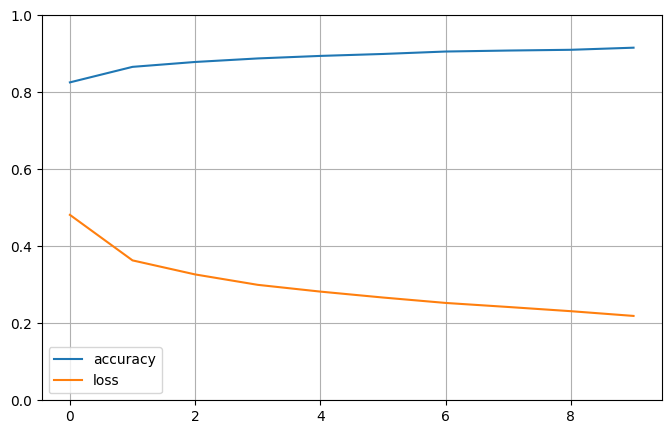

In [21]:
# Importuje bibliotekę Pandas, używaną do pracy z danymi tabelarycznymi.
import pandas as pd

# Importuje moduł pyplot, służący do tworzenia wykresów.
import matplotlib.pyplot as plt

# Pobiera historię treningu z obiektu train_stats.history,
# zamienia ją na tabelę DataFrame i tworzy wykres.
# Na wykresie mogą znaleźć się np. wartości loss i accuracy
# zapisane po każdej epoce treningu.
pd.DataFrame(train_stats.history).plot(figsize=(8, 5))

# Dodaje do wykresu siatkę ułatwiającą odczytywanie wartości.
plt.grid(True)

# Pobiera aktualne osie wykresu i ustawia zakres osi Y od 0 do 1.
plt.gca().set_ylim(0, 1)

# Wyświetla gotowy wykres.
plt.show()

Jak widać metryka (accuracy), rośnie z kolejnymi epokami, natomiast błąd (loss), maleje.

Tak powinno być!

W tym momencie przeszliśmy przez cały proces trenowania podstawowego modelu. Pozostała jeszcze jedna rzecz, aby mieć pełen obraz, jak korzystać z podstawowego interfejsu udostępnionego przez TensorFlow:

predykcja wyników na nowych danych.
Aby przewidzieć wynik dla nowych danych, możemy użyć metody predict():

In [22]:
import numpy as np
# Generuje przewidywania modelu dla wszystkich obrazów ze zbioru testowego.
# Każdy element y_pred zawiera 10 prawdopodobieństw — po jednym dla każdej klasy.
y_pred = f_mnist_model.predict(X_test)

# Wyświetla prawdopodobieństwa klas dla trzeciego obrazu testowego.
# Indeks 2 oznacza trzeci element, ponieważ indeksowanie zaczyna się od 0.
print("Prawdopodobieństwa:", y_pred[2])

# Znajduje indeks największego prawdopodobieństwa.
# Indeks ten jest numerem klasy przewidzianej przez model.
print("Przewidziana klasa:", np.argmax(y_pred[2]))

# Wyświetla prawdziwą klasę trzeciego obrazu ze zbioru testowego.
print("Rzeczywista klasa:", y_test[2])


"""
Przykładowy wynik:

Prawdopodobieństwa:
[4.0548810e-15 1.0000000e+00 9.3477974e-17 5.3090128e-13
 7.5702587e-15 5.9295928e-25 2.1536054e-11 3.4459677e-24
 2.8725664e-16 2.4974258e-22]

Przewidziana klasa: 1
Rzeczywista klasa: 1
"""

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Prawdopodobieństwa: [1.1667814e-02 2.1489620e-02 3.4788677e-01 2.6617786e-02 4.3248701e-01
 2.6398097e-04 1.4807536e-01 2.3215974e-03 3.7732618e-03 5.4168268e-03]
Przewidziana klasa: 4
Rzeczywista klasa: 2


'\nPrzykładowy wynik:\n\nPrawdopodobieństwa:\n[4.0548810e-15 1.0000000e+00 9.3477974e-17 5.3090128e-13\n 7.5702587e-15 5.9295928e-25 2.1536054e-11 3.4459677e-24\n 2.8725664e-16 2.4974258e-22]\n\nPrzewidziana klasa: 1\nRzeczywista klasa: 1\n'

onieważ w ostatniej warstwie naszego modelu użyliśmy funkcji aktywacyjnej softmas, uzyskujemy prawdopodobieństwa poszczególnych klas dla naszych danych.

Widać tutaj, że największe prawdopodobieństwo ma element 0, czyli nasze zdjęcie jest klasy 0. Klasa 0 według fashion_mnist to t-Shirt, ponadto rzeczywista klasa jest taka sama. Dodatkowo możemy wyświetlić sobie obraz indeksu 2:

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


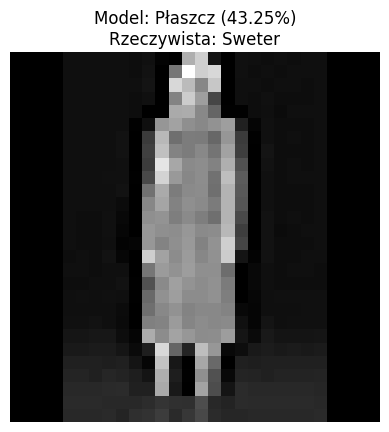

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Nazwy 10 klas ze zbioru Fashion MNIST.
class_names = [
    "T-shirt/top",
    "Spodnie",
    "Sweter",
    "Sukienka",
    "Płaszcz",
    "Sandał",
    "Koszula",
    "But",
    "Torba",
    "Botek"
]

# Wybiera trzeci obraz ze zbioru testowego.
index = 2

# Generuje przewidywanie dla wszystkich obrazów testowych.
y_pred = f_mnist_model.predict(X_test)

# Wybiera numer klasy z najwyższym prawdopodobieństwem.
predicted_class = np.argmax(y_pred[index])

# Pobiera prawdziwy numer klasy.
real_class = int(y_test[index])

# Wyświetla wybrany obraz.
plt.imshow(X_test[index], cmap="gray")

# Dodaje tytuł z przewidywaną i rzeczywistą klasą.
plt.title(
    f"Model: {class_names[predicted_class]} "
    f"({y_pred[index][predicted_class] * 100:.2f}%)\n"
    f"Rzeczywista: {class_names[real_class]}"
)

# Ukrywa osie i numery pikseli.
plt.axis("off")

# Wyświetla wykres.
plt.show()

Tadam! Nasz model działa. Skoro znamy już podstawy interfejsu TensorFlow, to nadeszła pora, aby przedstawić dwie inne metody tworzenia modeli.

# Functional API do stworzenia modelu w TensorFlow

Poprzednio przedstawiony model posiada jedną zasadniczą wadę: jest on sekwencyjny, czyli nie ma możliwości dostarczenia mu dwóch różnych wejść np. obrazu oraz tekstu naraz. Czasami jest to potrzebne np. w sytuacji, jeżeli chcemy zaimplementować coś zwanego Residual Layer (jedna z najczęściej używanych typów warstw, oczywiście z modyfikacjami), która jest głównym elementem składowym nowoczesnych sieci tzw, mającego poniższą formę:

Input Layer -> Hidden Layer 1 -> Hidden Layer 2 -> Concat Layer -> Output Layer

Albo kiedy chcemy dopasować opis do zdjęcia. Podczas szkolenia musimy dostarczyć zarówno opis słowny, jak i zdjęcie, jako wejście modelu.

W takim przypadku z pomocą przychodzi nam tzw. functional API.

Tworzenie takiego typu, bardziej skomplikowanych modeli, jest równie proste co zapisanie funkcji, jednak aby zbudować model przy pomocy Functional API potrzebna będzie jednak jeszcze jedna warstwa: Input Layer.

Musimy przekazać jej tylko jeden parametr:

shape – jak czytamy w dokumentacji, jest to rozmiar danych wejściowych, bez batch_size, czyli "czysty" rozmiar naszych danych.

Stwórzmy przykładowy model implementujący Residual Layer za pomocą Functional API:

In [24]:
# stworzenie wejścia

input = tf.keras.Input(shape=X_train.shape[1:])

# możemy wypisać, co ta warstwa przyjmuje - jest to rozmiar
# naszego obrazka bez batch_size (który ma wartość None)
print(input)

# spłaszczenie wejścia
input_flat = layers.Flatten(input_shape=[28,28])(input)

# nasza kolejna warstwa jest typu Dense, jak poprzednio, ale od razu
# i bezpośrednio przekazujemy jej wejście, tak jak funkcji w Pythonie:
hidden_1 =layers.Dense(320, activation='relu', name="hidden_1")(input_flat)
hidden_2 =layers.Dense(150, activation='relu', name="hidden_2")(hidden_1)

# złączamy wyniki z obu warstw za pomocą warstwy typu Concatenate
concat_layer = layers.Concatenate()([input_flat, hidden_2])
output = layers.Dense(10, activation='softmax')(concat_layer)

# tworzymy model, przekazując mu co ma być naszymi wyjściami, a co wejściami
model_res = tf.keras.Model(inputs=[input], outputs=[output])

# podsumowanie naszego modelu
model_res.summary()

<KerasTensor shape=(None, 28, 28), dtype=float32, sparse=False, ragged=False, name=keras_tensor_28>


C:\Users\micha\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 28, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_6 (Flatten) │ (None, 784)       │          0 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hidden_1 (Dense)    │ (None, 320)       │    251,200 │ flatten_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hidden_2 (Dense)    │ (None, 150)       │     48,150 │ hidden_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 934)       │          0 │ flatten_6[0][0],  │
│ (Concatenate)       │                   │            │ hidden_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 10)        │      9,350 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 308,700 (1.18 MB)

 Trainable params: 308,700 (1.18 MB)

 Non-trainable params: 0 (0.00 B)

Widać tutaj, że po wykreowaniu naszych warstw musimy jeszcze stworzyć model. Jak było powiedziane w tym module, wszystkie modele, nieważne w jaki sposób stworzone, dziedziczą po klasie tf.keras.Model. Widać to tutaj, kiedy tworzymy nasz końcowy model. Musimy mu podać wejścia i wyjścia, jako wektory i gotowe.



Dzieje się to, czego oczekiwaliśmy, czyli mamy sumowanie wejść i przekazywanie dalej.

Stwórzmy teraz drugi model, z dwoma wyjściami dla tekstu:

In [25]:
text = np.array([["ala ma kota"]])

input_1 = tf.keras.Input(shape=text.shape[1:])
input_2 = tf.keras.Input(shape=X_train.shape[1:])

# nasza kolejna warstwa jest typu Dense, jak poprzednio,
# ale od razu przekazujemy jej wejście, tak jak funkcji w Pythonie
hidden_1 =layers.Dense(320, activation='relu')(input_1)
hidden_2 =layers.Dense(150, activation='relu')(hidden_1)

# złączamy wyniki naszych warstw za pomocą warstwy
# typu Concatenate podając jako argumenty input_1 oraz hidden_2
concat_layer = layers.Concatenate()([input_1, hidden_2])
output = layers.Dense(10, activation='softmax')(concat_layer)

# tworzymy model, przekazując mu co ma być naszymi wyjściami, a co wejściami
model = tf.keras.Model(inputs=[input_1, input_2], outputs=[output])

# podsumowanie naszego modelu
model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 320)       │        640 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 150)       │     48,150 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 151)       │          0 │ input_layer_6[0]… │
│ (Concatenate)       │                   │            │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, 28, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 10)        │      1,520 │ concatenate_1[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 50,310 (196.52 KB)

 Trainable params: 50,310 (196.52 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# kompilacja
model_res.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

#szkolenie na takich samych danych jak poprzednio
train_stats = model_res.fit(train_ds, epochs=10, verbose=1)

Epoch 1/10


C:\Users\micha\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.8234 - loss: 0.4897
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.8635 - loss: 0.3675
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.8794 - loss: 0.3264
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - accuracy: 0.8875 - loss: 0.3016
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.8939 - loss: 0.2842
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9011 - loss: 0.2665
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - accuracy: 0.9039 - loss: 0.2558
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - accuracy: 0.9080 - loss: 0.2429
Epoch 9/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9118 - loss: 0.2330
Epoch 10/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9145 - loss: 0.2236
